# Predictive Maintenance Pipeline — Industrial Centrifugal Pumps


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from sklearn.metrics import recall_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

import pdm_utils as u

RANDOM_STATE = u.RANDOM_STATE
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
CAT = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]
STATUS = {"Normal": "#0ca30c", "Warning": "#fab219", "Critical": "#d03b3b"}
SEQ_BLUE = "#2a78d6"
CLASS_NAMES = u.CLASS_NAMES
CLASS_COLORS = [STATUS["Normal"], STATUS["Warning"], STATUS["Critical"], "#e34948", "#e87ba4", "#eb6834"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_style("whitegrid", {"axes.facecolor": SURFACE, "grid.color": GRID})

DATA_PATH = "data/AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx"
FIG_DIR = "outputs/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Dataset Understanding


In [2]:
df_raw = u.load_raw_data(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 10,000 rows x 10 columns


,Timestamp,Asset_ID,Machine_Model,Location,Vibration_mm_s,Temperature_C,Pressure_psi,Flow_Rate_m3_h,RUL_Hours,Failure_State
0,2026-01-01 00:00:00,PUMP_001,Hydra-500,Onshore-Terminal-2,2.3,57.4,145.7,248.9,500,Normal
1,2026-01-01 01:00:00,PUMP_002,Nova-P,Onshore-Terminal-1,1.5,59.8,147.9,247.2,499,Normal
2,2026-01-01 02:00:00,PUMP_003,Nova-P,Offshore-Platform-B,2.2,60.5,145.0,252.6,498,Normal
3,2026-01-01 03:00:00,PUMP_004,Nova-P,Offshore-Platform-B,2.5,56.7,148.2,248.5,497,Normal
4,2026-01-01 04:00:00,PUMP_005,Hydra-500,Onshore-Terminal-1,2.4,66.7,140.6,254.7,496,Normal


In [3]:
print("Data types:")
print(df_raw.dtypes)
print()
numerical_cols = ["Vibration_mm_s", "Temperature_C", "Pressure_psi", "Flow_Rate_m3_h", "RUL_Hours"]
categorical_cols = ["Asset_ID", "Machine_Model", "Location", "Failure_State"]
print(f"Numerical columns:   {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print()
print("Classification target : Failure_State -> 3-class health stage 'Failure_Class'")
print("  (Normal / Warning / Critical -- Bearing_Failure, Motor_Failure, Seal_Failure")
print("  folded into Critical; component-level fault typing moves to a separate")
print("  rule-based module, app/fault_diagnosis.py, that only runs on Critical")
print("  predictions -- see Stage 3 and Stage 9 for the mapping and its baseline stats)")
print("Regression target     : RUL_Hours")


Data types:
Timestamp             str
Asset_ID              str
Machine_Model         str
Location              str
Vibration_mm_s    float64
Temperature_C     float64
Pressure_psi      float64
Flow_Rate_m3_h    float64
RUL_Hours           int64
Failure_State         str
dtype: object

Numerical columns:   ['Vibration_mm_s', 'Temperature_C', 'Pressure_psi', 'Flow_Rate_m3_h', 'RUL_Hours']
Categorical columns: ['Asset_ID', 'Machine_Model', 'Location', 'Failure_State']

Classification target : Failure_State -> 3-class health stage 'Failure_Class'
  (Normal / Warning / Critical -- Bearing_Failure, Motor_Failure, Seal_Failure
  folded into Critical; component-level fault typing moves to a separate
  rule-based module, app/fault_diagnosis.py, that only runs on Critical
  predictions -- see Stage 3 and Stage 9 for the mapping and its baseline stats)
Regression target     : RUL_Hours


In [4]:
n_assets = df_raw["Asset_ID"].nunique()
print(f"Unique pumps (Asset_ID): {n_assets}")
print(f"Readings per pump: {df_raw['Asset_ID'].value_counts().unique()}")
print(f"Timestamp range: {df_raw['Timestamp'].min()} -> {df_raw['Timestamp'].max()}")
print()
print("Failure_State value counts:")
print(df_raw["Failure_State"].value_counts())

Unique pumps (Asset_ID): 20
Readings per pump: [500]
Timestamp range: 2026-01-01 00:00:00 -> 2027-02-21 15:00:00

Failure_State value counts:
Failure_State
Normal             9000
Warning             800
Critical            180
Bearing_Failure       9
Motor_Failure         7
Seal_Failure          4
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)


In [5]:
print("=== Overview ===")
df_raw.info()

=== Overview ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       10000 non-null  str    
 1   Asset_ID        10000 non-null  str    
 2   Machine_Model   10000 non-null  str    
 3   Location        10000 non-null  str    
 4   Vibration_mm_s  10000 non-null  float64
 5   Temperature_C   10000 non-null  float64
 6   Pressure_psi    10000 non-null  float64
 7   Flow_Rate_m3_h  10000 non-null  float64
 8   RUL_Hours       10000 non-null  int64  
 9   Failure_State   10000 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [6]:
print("=== Missing values ===")
print(df_raw.isnull().sum())
print()
print(f"=== Duplicate rows: {df_raw.duplicated().sum()} ===")

=== Missing values ===
Timestamp         0
Asset_ID          0
Machine_Model     0
Location          0
Vibration_mm_s    0
Temperature_C     0
Pressure_psi      0
Flow_Rate_m3_h    0
RUL_Hours         0
Failure_State     0
dtype: int64

=== Duplicate rows: 0 ===


In [7]:
print("=== Summary statistics (numerical) ===")
df_raw[numerical_cols].describe().T

=== Summary statistics (numerical) ===


,count,mean,std,min,25%,50%,75%,max
Vibration_mm_s,10000.0,2.32281,1.193184,1.2,1.60,2.1,2.50,12.4
Temperature_C,10000.0,64.61187,8.231399,55.0,59.20,63.3,67.50,119.3
Pressure_psi,10000.0,143.73423,5.480398,90.6,141.70,144.4,147.20,150.0
Flow_Rate_m3_h,10000.0,248.09529,7.858274,160.0,246.60,249.4,252.20,255.0
RUL_Hours,10000.0,250.49800,144.347960,0.0,125.75,250.5,375.25,500.0


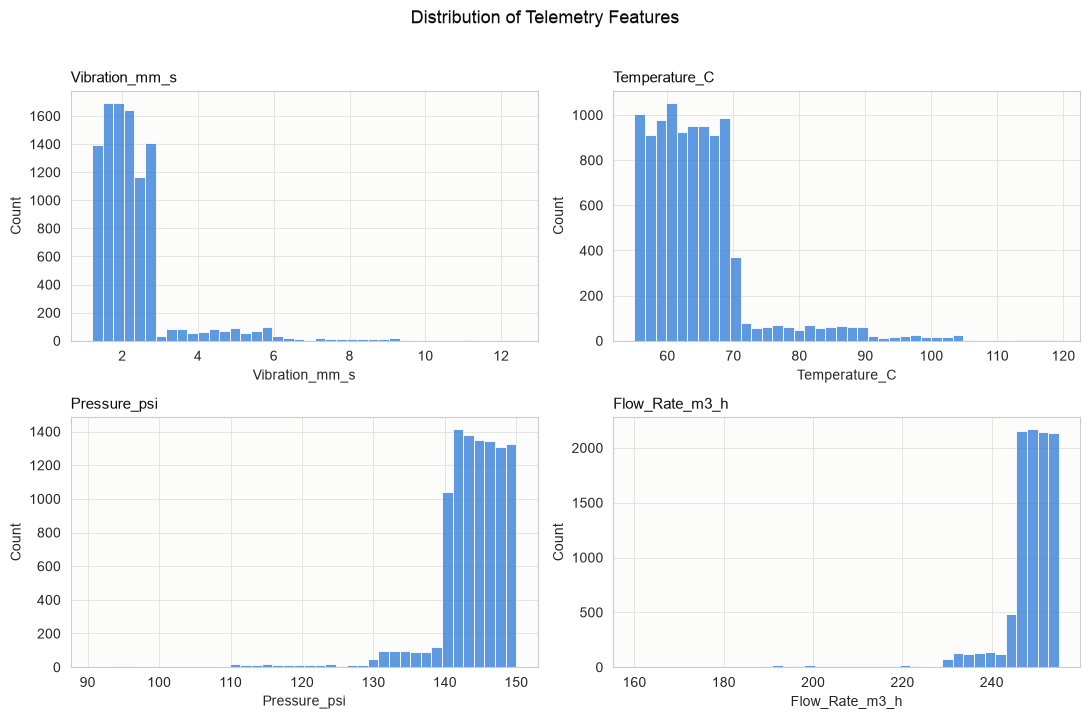

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
telemetry_cols = ["Vibration_mm_s", "Temperature_C", "Pressure_psi", "Flow_Rate_m3_h"]
for ax, col in zip(axes.flat, telemetry_cols):
    sns.histplot(df_raw[col], bins=40, color=SEQ_BLUE, edgecolor=SURFACE, ax=ax)
    ax.set_title(col, color=INK_PRIMARY, fontsize=11, loc="left")
    ax.set_ylabel("Count")
fig.suptitle("Distribution of Telemetry Features", fontsize=13, color=INK_PRIMARY, y=1.02)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_telemetry_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

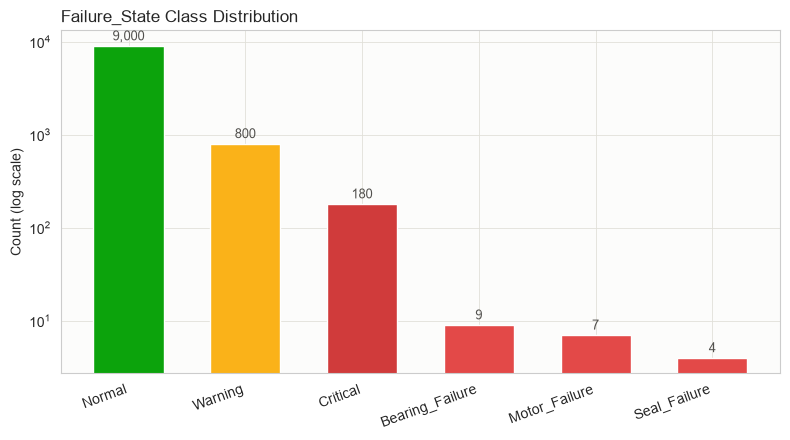

In [9]:
order = ["Normal", "Warning", "Critical", "Bearing_Failure", "Motor_Failure", "Seal_Failure"]
counts = df_raw["Failure_State"].value_counts().reindex(order)
colors = [STATUS.get(s, "#e34948") for s in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(order, counts.values, color=colors, width=0.6)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Failure_State Class Distribution", loc="left", fontsize=12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15, f"{val:,}", ha="center", fontsize=9, color=INK_SECONDARY)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_failure_state_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

In [10]:
sensor_ranges = df_raw.groupby("Failure_State")[telemetry_cols].agg(["min", "max"])
sensor_ranges = sensor_ranges.reindex(order)
sensor_ranges

Vibration_mm_s       Temperature_C        Pressure_psi        Flow_Rate_m3_h       
                           min   max           min    max          min    max            min    max
Failure_State                                                                                      
Normal                     1.2   2.8          55.0   70.0        140.0  150.0          245.0  255.0
Warning                    3.0   6.0          70.1   90.0        130.0  142.0          230.0  245.0
Critical                   6.0   9.5          90.1  105.0        110.1  130.0          190.0  224.5
Bearing_Failure            9.8  12.3         105.5  119.3         90.6  102.0          160.0  193.0
Motor_Failure             10.8  12.1         108.7  115.7         94.7  105.8          180.7  194.0
Seal_Failure              10.0  12.4         110.4  117.7         96.2  107.6          175.7  182.7

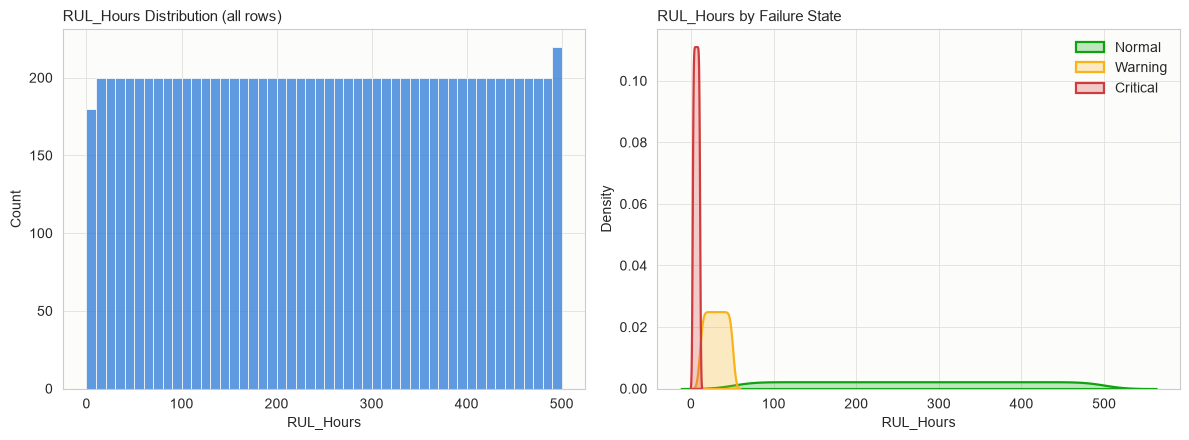

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_raw["RUL_Hours"], bins=50, color=SEQ_BLUE, edgecolor=SURFACE, ax=axes[0])
axes[0].set_title("RUL_Hours Distribution (all rows)", loc="left", fontsize=11)

for state, color in STATUS.items():
    sns.kdeplot(df_raw.loc[df_raw["Failure_State"] == state, "RUL_Hours"], ax=axes[1], color=color, label=state, fill=True, alpha=0.25, linewidth=1.6)
axes[1].set_title("RUL_Hours by Failure State", loc="left", fontsize=11)
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_rul_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

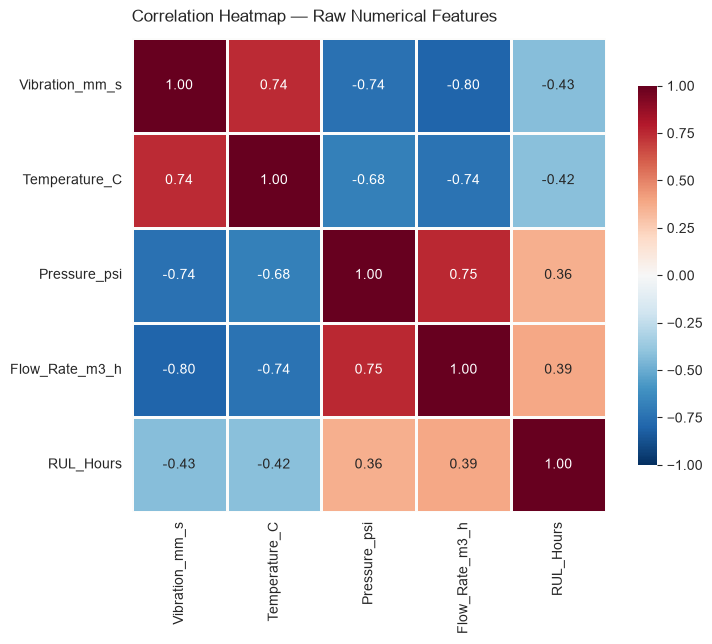

In [12]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df_raw[numerical_cols].corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=1, linecolor=SURFACE, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Correlation Heatmap — Raw Numerical Features", loc="left", fontsize=12, pad=12)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

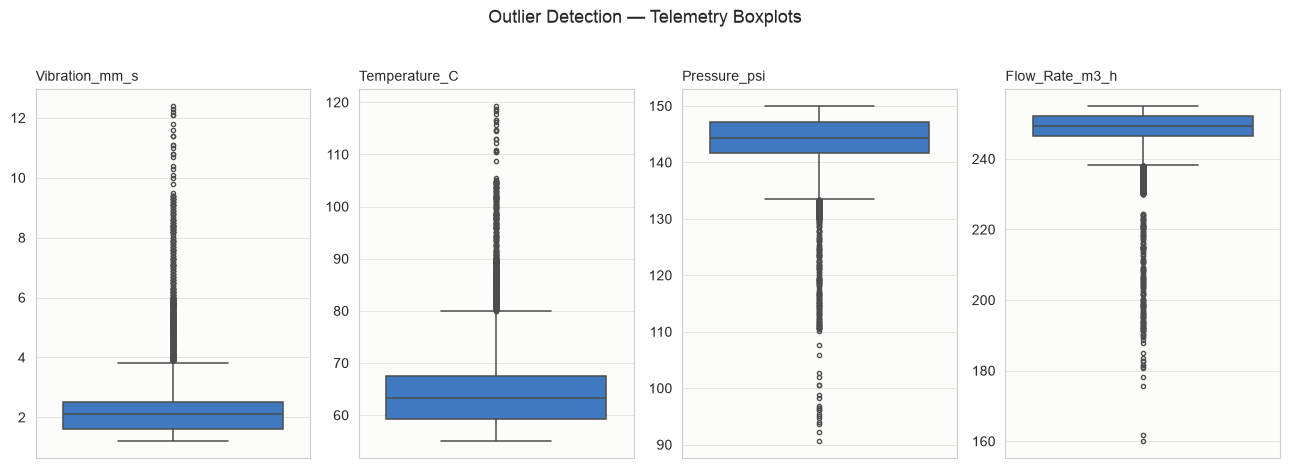

IQR-rule outlier counts:
  Vibration_mm_s: 766 (7.66%)
  Temperature_C: 598 (5.98%)
  Pressure_psi: 420 (4.20%)
  Flow_Rate_m3_h: 639 (6.39%)


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for ax, col in zip(axes, telemetry_cols):
    sns.boxplot(y=df_raw[col], ax=ax, color=SEQ_BLUE, fliersize=3, linewidth=1.1)
    ax.set_title(col, fontsize=10, loc="left")
    ax.set_ylabel("")
fig.suptitle("Outlier Detection — Telemetry Boxplots", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_outlier_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()

def iqr_outlier_count(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

print("IQR-rule outlier counts:")
for col in telemetry_cols:
    print(f"  {col}: {iqr_outlier_count(df_raw[col])} ({iqr_outlier_count(df_raw[col]) / len(df_raw):.2%})")

## 3. Data Preprocessing


In [14]:
df = u.parse_and_sort_timestamps(df_raw)
df, n_dupes_dropped = u.drop_duplicates_and_report(df)
df = u.handle_missing_values(df, u.RAW_NUMERIC_COLS)
print(f"Duplicates dropped: {n_dupes_dropped}")
print(f"Remaining missing values: {df[u.RAW_NUMERIC_COLS].isnull().sum().sum()}")

encoders = u.LabelEncoders()
df = encoders.fit_transform(df, ["Machine_Model"])

df = u.map_failure_state_classes(df)
print()
print("Failure_Class value counts (0=Normal, 1=Warning, 2=Critical):")
print(df["Failure_Class"].value_counts().sort_index())
print(f"Class name order: {u.CLASS_NAMES}")
print(f"Rows folded from a terminal failure state into Critical: {int(df['Is_Terminal_Failure'].sum())}")
df[["Asset_ID", "Timestamp", "Machine_Model", "Machine_Model_Encoded", "Failure_State", "Health_State", "Failure_Class", "Is_Terminal_Failure", "RUL_Hours"]].head()


Duplicates dropped: 0
Remaining missing values: 0

Failure_Class value counts (0=Normal, 1=Warning, 2=Critical):
Failure_Class
0    9000
1     800
2     200
Name: count, dtype: int64
Class name order: ['Normal', 'Warning', 'Critical']
Rows folded from a terminal failure state into Critical: 20


,Asset_ID,Timestamp,Machine_Model,Machine_Model_Encoded,Failure_State,Health_State,Failure_Class,Is_Terminal_Failure,RUL_Hours
0,PUMP_001,2026-01-01 00:00:00,Hydra-500,1,Normal,Normal,0,False,500
1,PUMP_001,2026-01-01 20:00:00,Titan-X2,3,Normal,Normal,0,False,480
2,PUMP_001,2026-01-02 16:00:00,Hydra-500,1,Normal,Normal,0,False,460
3,PUMP_001,2026-01-03 12:00:00,Nova-P,2,Normal,Normal,0,False,440
4,PUMP_001,2026-01-04 08:00:00,Titan-X3,4,Normal,Normal,0,False,420


In [15]:
fault_diagnosis_baseline = u.compute_fault_diagnosis_baseline(df)
print("Fault-diagnosis baseline (Normal-state mean/std per raw channel):")
print(json.dumps(fault_diagnosis_baseline, indent=2))


Fault-diagnosis baseline (Normal-state mean/std per raw channel):
{
  "Vibration_mm_s": {
    "mean": 2.001377777777778,
    "std": 0.4639130822451112
  },
  "Temperature_C": {
    "mean": 62.47364444444445,
    "std": 4.315357469064644
  },
  "Pressure_psi": {
    "mean": 144.99466666666666,
    "std": 2.888394148633802
  },
  "Flow_Rate_m3_h": {
    "mean": 250.00386666666665,
    "std": 2.886320154029879
  }
}


## 4. Feature Engineering


In [16]:
df_fe = u.engineer_all_features(df)
new_feature_cols = [c for c in df_fe.columns if c not in df.columns]
print(f"Engineered {len(new_feature_cols)} new features (total columns: {df_fe.shape[1]})")
print()
for group_label, needle in [("Rolling", "Rolling"), ("Lag", "_t-"), ("Rate/Pct change", "Change"), ("Interaction", "_x_")]:
    matched = [c for c in new_feature_cols if needle in c]
    print(f"{group_label} ({len(matched)}): {matched}")

Engineered 48 new features (total columns: 62)

Rolling (24): ['Vibration_mm_s_Rolling_Mean_4h', 'Vibration_mm_s_Rolling_Std_4h', 'Vibration_mm_s_Rolling_Mean_12h', 'Vibration_mm_s_Rolling_Std_12h', 'Vibration_mm_s_Rolling_Mean_24h', 'Vibration_mm_s_Rolling_Std_24h', 'Temperature_C_Rolling_Mean_4h', 'Temperature_C_Rolling_Std_4h', 'Temperature_C_Rolling_Mean_12h', 'Temperature_C_Rolling_Std_12h', 'Temperature_C_Rolling_Mean_24h', 'Temperature_C_Rolling_Std_24h', 'Pressure_psi_Rolling_Mean_4h', 'Pressure_psi_Rolling_Std_4h', 'Pressure_psi_Rolling_Mean_12h', 'Pressure_psi_Rolling_Std_12h', 'Pressure_psi_Rolling_Mean_24h', 'Pressure_psi_Rolling_Std_24h', 'Flow_Rate_m3_h_Rolling_Mean_4h', 'Flow_Rate_m3_h_Rolling_Std_4h', 'Flow_Rate_m3_h_Rolling_Mean_12h', 'Flow_Rate_m3_h_Rolling_Std_12h', 'Flow_Rate_m3_h_Rolling_Mean_24h', 'Flow_Rate_m3_h_Rolling_Std_24h']
Lag (12): ['Vibration_mm_s_t-1', 'Vibration_mm_s_t-2', 'Vibration_mm_s_t-3', 'Temperature_C_t-1', 'Temperature_C_t-2', 'Temperature_C_t

In [17]:
sample = df_fe[df_fe["Asset_ID"] == "PUMP_020"].tail(8)
sample[["Timestamp", "Vibration_mm_s", "Vibration_mm_s_Rolling_Mean_4h", "Vibration_mm_s_Rolling_Std_4h", "Vibration_mm_s_t-1", "Vibration_mm_s_Rate_of_Change", "Failure_State"]]

,Timestamp,Vibration_mm_s,Vibration_mm_s_Rolling_Mean_4h,Vibration_mm_s_Rolling_Std_4h,Vibration_mm_s_t-1,Vibration_mm_s_Rate_of_Change,Failure_State
9992,2027-02-15 19:00:00,1.7,2.050,0.300000,2.3,-0.6,Normal
9993,2027-02-16 15:00:00,2.6,2.125,0.403113,1.7,0.9,Normal
9994,2027-02-17 11:00:00,2.3,2.225,0.377492,2.6,-0.3,Normal
9995,2027-02-18 07:00:00,1.4,2.000,0.547723,2.3,-0.9,Normal
9996,2027-02-19 03:00:00,1.2,1.875,0.680074,1.4,-0.2,Normal
9997,2027-02-19 23:00:00,5.7,2.650,2.088859,1.2,4.5,Warning
9998,2027-02-20 19:00:00,3.7,3.000,2.127596,5.7,-2.0,Warning
9999,2027-02-21 15:00:00,12.1,5.675,4.662170,3.7,8.4,Motor_Failure


## 5. Feature Selection


In [18]:
EXCLUDE_COLS = [
    "Timestamp", "Asset_ID", "Location", "Machine_Model",
    "Failure_State", "Health_State", "Failure_Class", "Is_Terminal_Failure", "RUL_Hours",
]
feature_candidates = [c for c in df_fe.columns if c not in EXCLUDE_COLS]
print(f"{len(feature_candidates)} candidate features before pruning")

preferred_order = sorted(
    feature_candidates,
    key=lambda c: (("Pct_Change" in c) or ("_x_" in c and c not in ("Vibration_mm_s",)), c),
)
kept_features, dropped_pairs = u.remove_correlated_features(df_fe, preferred_order, threshold=0.9)
print(f"{len(kept_features)} features kept after correlation pruning ({len(dropped_pairs)} dropped)")
print()
print("Dropped as redundant (kept_feature ~ dropped_feature : |r|):")
for keep, drop, r in dropped_pairs:
    print(f"  {keep} ~ {drop} : {r:.3f}")


53 candidate features before pruning
42 features kept after correlation pruning (11 dropped)

Dropped as redundant (kept_feature ~ dropped_feature : |r|):
  Flow_Rate_m3_h_Rolling_Std_12h ~ Flow_Rate_m3_h_Rolling_Mean_12h : 0.912
  Vibration_mm_s_Rolling_Std_12h ~ Temperature_C_Rolling_Std_12h : 0.901
  Vibration_mm_s_Rolling_Std_12h ~ Vibration_mm_s_Rolling_Mean_12h : 0.904
  Flow_Rate_m3_h_Pct_Change ~ Flow_Rate_m3_h_Rate_of_Change : 0.993
  Flow_x_Pressure ~ Flow_Rate_m3_h : 0.917
  Flow_x_Pressure ~ Pressure_psi : 0.950
  Pressure_psi_Pct_Change ~ Pressure_psi_Rate_of_Change : 0.990
  Temp_x_Pressure ~ Temperature_C : 0.927
  Temperature_C_Pct_Change ~ Temperature_C_Rate_of_Change : 0.979
  Vibration_x_Pressure ~ Vibration_mm_s : 0.988
  Vibration_x_Temp ~ Vibration_x_Pressure : 0.940


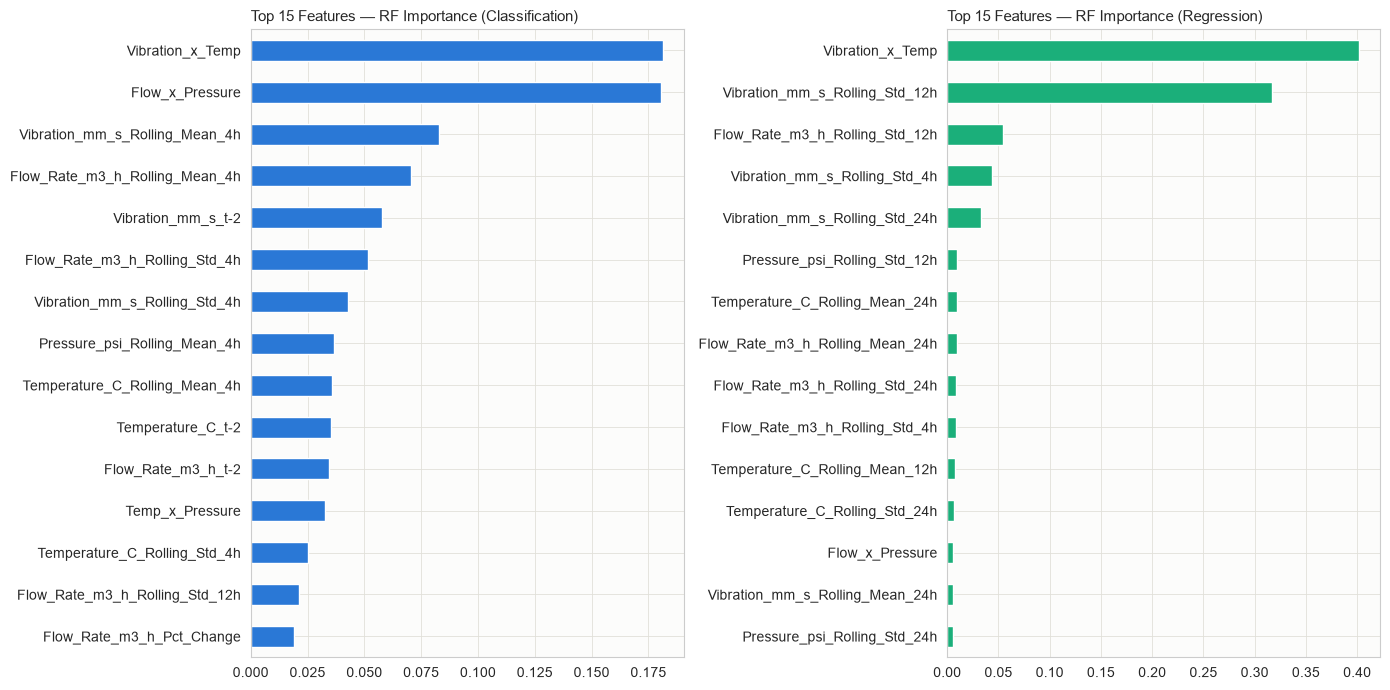

In [19]:
X_class_full = df_fe[kept_features]
y_class_full = df_fe["Failure_Class"].astype(int)
X_reg_full = df_fe[kept_features]
y_reg_full = df_fe["RUL_Hours"]

rf_imp_clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf_imp_clf.fit(X_class_full, y_class_full)
importance_clf = pd.Series(rf_imp_clf.feature_importances_, index=kept_features).sort_values(ascending=False)

rf_imp_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp_reg.fit(X_reg_full, y_reg_full)
importance_reg = pd.Series(rf_imp_reg.feature_importances_, index=kept_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
importance_clf.head(15).sort_values().plot.barh(ax=axes[0], color=CAT[0])
axes[0].set_title("Top 15 Features — RF Importance (Classification)", loc="left", fontsize=11)
importance_reg.head(15).sort_values().plot.barh(ax=axes[1], color=CAT[1])
axes[1].set_title("Top 15 Features — RF Importance (Regression)", loc="left", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

In [20]:
mi_clf = pd.Series(
    mutual_info_classif(X_class_full, y_class_full, random_state=RANDOM_STATE),
    index=kept_features,
).sort_values(ascending=False)
mi_reg = pd.Series(
    mutual_info_regression(X_reg_full, y_reg_full, random_state=RANDOM_STATE),
    index=kept_features,
).sort_values(ascending=False)

print("Top 10 features by Mutual Information (classification):")
print(mi_clf.head(10))
print()
print("Top 10 features by Mutual Information (regression):")
print(mi_reg.head(10))

Top 10 features by Mutual Information (classification):
Vibration_x_Temp                  0.375145
Flow_x_Pressure                   0.369958
Temp_x_Pressure                   0.235941
Flow_Rate_m3_h_Pct_Change         0.200036
Flow_Rate_m3_h_Rolling_Std_4h     0.193765
Vibration_mm_s_Rolling_Std_4h     0.191502
Vibration_mm_s_Rolling_Mean_4h    0.180194
Vibration_mm_s_Rate_of_Change     0.173221
Flow_Rate_m3_h_Rolling_Mean_4h    0.167383
Vibration_mm_s_Pct_Change         0.165980
dtype: float64

Top 10 features by Mutual Information (regression):
Vibration_mm_s_Rolling_Std_12h    0.834216
Flow_Rate_m3_h_Rolling_Std_12h    0.826407
Pressure_psi_Rolling_Std_12h      0.687422
Temperature_C_Rolling_Mean_12h    0.567785
Vibration_mm_s_Rolling_Mean_4h    0.555517
Flow_Rate_m3_h_Rolling_Std_4h     0.548926
Vibration_mm_s_Rolling_Std_4h     0.531392
Flow_Rate_m3_h_Rolling_Mean_4h    0.523387
Flow_Rate_m3_h_Rolling_Std_24h    0.503868
Pressure_psi_Rolling_Mean_12h     0.487029
dtype: float64


In [21]:
rfe_clf = RFE(
    DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    n_features_to_select=15, step=3,
)
rfe_clf.fit(X_class_full, y_class_full)
rfe_clf_selected = set(X_class_full.columns[rfe_clf.support_])

rfe_reg = RFE(
    DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    n_features_to_select=15, step=3,
)
rfe_reg.fit(X_reg_full, y_reg_full)
rfe_reg_selected = set(X_reg_full.columns[rfe_reg.support_])

print(f"RFE selected (classification): {sorted(rfe_clf_selected)}")
print()
print(f"RFE selected (regression): {sorted(rfe_reg_selected)}")

RFE selected (classification): ['Flow_Rate_m3_h_Pct_Change', 'Flow_x_Pressure', 'Pressure_psi_Pct_Change', 'Temp_x_Pressure', 'Temperature_C_Pct_Change', 'Temperature_C_t-2', 'Vibration_mm_s_Pct_Change', 'Vibration_mm_s_Rolling_Mean_4h', 'Vibration_mm_s_Rolling_Std_12h', 'Vibration_mm_s_Rolling_Std_24h', 'Vibration_mm_s_Rolling_Std_4h', 'Vibration_mm_s_t-1', 'Vibration_mm_s_t-2', 'Vibration_mm_s_t-3', 'Vibration_x_Temp']

RFE selected (regression): ['Flow_Rate_m3_h_Rolling_Mean_24h', 'Flow_Rate_m3_h_Rolling_Mean_4h', 'Flow_Rate_m3_h_Rolling_Std_12h', 'Flow_Rate_m3_h_Rolling_Std_24h', 'Pressure_psi_Rolling_Std_12h', 'Temperature_C_Rolling_Mean_12h', 'Temperature_C_Rolling_Mean_24h', 'Temperature_C_Rolling_Std_24h', 'Temperature_C_Rolling_Std_4h', 'Vibration_mm_s_Rolling_Std_12h', 'Vibration_mm_s_Rolling_Std_24h', 'Vibration_mm_s_Rolling_Std_4h', 'Vibration_mm_s_t-2', 'Vibration_mm_s_t-3', 'Vibration_x_Temp']


In [22]:
top_n = 15
union_selected = (
    set(importance_clf.head(top_n).index) | set(importance_reg.head(top_n).index)
    | set(mi_clf.head(top_n).index) | set(mi_reg.head(top_n).index)
    | rfe_clf_selected | rfe_reg_selected
)
final_features = [c for c in kept_features if c in union_selected]
print(f"Final recommended feature set: {len(final_features)} features (from {len(feature_candidates)} originally engineered)")
for f in final_features:
    print(f"  - {f}")

Final recommended feature set: 33 features (from 53 originally engineered)
  - Flow_Rate_m3_h_Rolling_Mean_24h
  - Flow_Rate_m3_h_Rolling_Mean_4h
  - Flow_Rate_m3_h_Rolling_Std_12h
  - Flow_Rate_m3_h_Rolling_Std_24h
  - Flow_Rate_m3_h_Rolling_Std_4h
  - Flow_Rate_m3_h_t-2
  - Pressure_psi_Rolling_Mean_12h
  - Pressure_psi_Rolling_Mean_4h
  - Pressure_psi_Rolling_Std_12h
  - Pressure_psi_Rolling_Std_24h
  - Pressure_psi_Rolling_Std_4h
  - Temperature_C_Rolling_Mean_12h
  - Temperature_C_Rolling_Mean_24h
  - Temperature_C_Rolling_Mean_4h
  - Temperature_C_Rolling_Std_24h
  - Temperature_C_Rolling_Std_4h
  - Temperature_C_t-2
  - Vibration_mm_s_Rate_of_Change
  - Vibration_mm_s_Rolling_Mean_24h
  - Vibration_mm_s_Rolling_Mean_4h
  - Vibration_mm_s_Rolling_Std_12h
  - Vibration_mm_s_Rolling_Std_24h
  - Vibration_mm_s_Rolling_Std_4h
  - Vibration_mm_s_t-1
  - Vibration_mm_s_t-2
  - Vibration_mm_s_t-3
  - Flow_Rate_m3_h_Pct_Change
  - Flow_x_Pressure
  - Pressure_psi_Pct_Change
  - Temp_x_Pr

## 6. Prepare Data


In [23]:
train_df, test_df = u.group_aware_time_split(df_fe)
X_train, X_test = train_df[final_features], test_df[final_features]

y_train_clf, y_test_clf = train_df["Failure_Class"].astype(int), test_df["Failure_Class"].astype(int)
y_train_reg, y_test_reg = train_df["RUL_Hours"], test_df["RUL_Hours"]

print("Shared feature matrix:")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print()
print("Classification target (Failure_Class):")
print(f"  Train counts: {y_train_clf.value_counts().sort_index().to_dict()}")
print(f"  Test counts:  {y_test_clf.value_counts().sort_index().to_dict()}")
print()
print("Regression target (RUL_Hours):")
print(f"  Train range: [{y_train_reg.min()}, {y_train_reg.max()}]")
print(f"  Test range:  [{y_test_reg.min()}, {y_test_reg.max()}]")

scaler = u.FeatureScaler(final_features)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print()
print("Scaled feature sample (train):")
X_train_scaled.head(3)

Shared feature matrix:
  Train: (8000, 33), Test: (2000, 33)

Classification target (Failure_Class):
  Train counts: {0: 7200, 1: 640, 2: 160}
  Test counts:  {0: 1800, 1: 160, 2: 40}

Regression target (RUL_Hours):
  Train range: [0, 500]
  Test range:  [0, 500]

Scaled feature sample (train):


,Flow_Rate_m3_h_Rolling_Mean_24h,Flow_Rate_m3_h_Rolling_Mean_4h,Flow_Rate_m3_h_Rolling_Std_12h,Flow_Rate_m3_h_Rolling_Std_24h,Flow_Rate_m3_h_Rolling_Std_4h,Flow_Rate_m3_h_t-2,Pressure_psi_Rolling_Mean_12h,Pressure_psi_Rolling_Mean_4h,Pressure_psi_Rolling_Std_12h,Pressure_psi_Rolling_Std_24h,Pressure_psi_Rolling_Std_4h,Temperature_C_Rolling_Mean_12h,Temperature_C_Rolling_Mean_24h,Temperature_C_Rolling_Mean_4h,Temperature_C_Rolling_Std_24h,Temperature_C_Rolling_Std_4h,Temperature_C_t-2,Vibration_mm_s_Rate_of_Change,Vibration_mm_s_Rolling_Mean_24h,Vibration_mm_s_Rolling_Mean_4h,Vibration_mm_s_Rolling_Std_12h,Vibration_mm_s_Rolling_Std_24h,Vibration_mm_s_Rolling_Std_4h,Vibration_mm_s_t-1,Vibration_mm_s_t-2,Vibration_mm_s_t-3,Flow_Rate_m3_h_Pct_Change,Flow_x_Pressure,Pressure_psi_Pct_Change,Temp_x_Pressure,Temperature_C_Pct_Change,Vibration_mm_s_Pct_Change,Vibration_x_Temp
0,0.541242,0.159529,-1.315509,-2.091817,-0.895359,0.092848,1.097073,0.591126,-1.754220,-2.678065,-1.216910,-2.657759,-5.003175,-1.407734,-3.632555,-1.365227,-0.877671,-0.008085,-0.038105,-0.015455,-1.537000,-2.740468,-1.039870,-0.010643,-0.00582,-0.003081,-0.014108,0.260735,-0.017969,-0.989789,-0.074234,-0.202803,-0.211510
1,2.591868,0.730384,-0.500857,-0.967321,-0.189664,0.092848,2.272831,1.217307,-0.678870,-1.177025,-0.327881,-1.851148,-3.480275,-0.983396,-2.223896,-0.664743,-0.877671,-0.376822,-1.428728,-0.354443,-0.969752,-1.857845,-0.551667,-0.010643,-0.00582,-0.003081,0.470857,1.082750,0.499867,-0.024243,0.484592,-0.641308,-0.386281
2,2.888499,0.812960,-0.721658,-1.272101,-0.380933,0.092848,1.998488,1.071198,-0.934082,-1.533265,-0.538873,-1.069548,-2.004596,-0.572216,-1.686556,-0.397540,-0.877671,-0.155580,-2.263102,-0.557836,-0.958518,-1.840365,-0.541999,-0.439802,-0.00582,-0.003081,-0.148500,0.584797,-0.446368,0.407003,0.421465,-0.426928,-0.434477


## 7. Train Machine Learning Models — 7a. Classification


In [24]:
sample_weight_train_clf = compute_sample_weight("balanced", y_train_clf)
all_class_labels = list(range(len(CLASS_NAMES)))

classifiers = {
    "Decision Tree (Baseline)": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective="multi:softprob", eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    ),
}

classification_results = []
fitted_classifiers = {}
for name, model in classifiers.items():
    if name == "XGBoost":
        model.fit(X_train, y_train_clf, sample_weight=sample_weight_train_clf)
    else:
        model.fit(X_train, y_train_clf)
    fitted_classifiers[name] = model
    result = u.evaluate_classifier(
        name, model, X_test, y_test_clf, X_train, y_train_clf, labels=all_class_labels
    )
    classification_results.append(result)
    print(f"{name:28s} done.")

Decision Tree (Baseline)     done.


Random Forest                done.


XGBoost                      done.


LightGBM                     done.


In [25]:
class_metrics_df = pd.DataFrame(classification_results).drop(
    columns=["_confusion_matrix", "_confusion_matrix_labels", "_y_pred"]
)
class_metrics_df = class_metrics_df.set_index("Model").round(4)
class_metrics_df

,Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_F1_Mean,CV_F1_Std
Model,,,,,,,
Decision Tree (Baseline),1.0,1.0,1.0,1.0,1.0,1.0000,0.0000
Random Forest,1.0,1.0,1.0,1.0,1.0,1.0000,0.0000
XGBoost,1.0,1.0,1.0,1.0,1.0,0.9997,0.0006
LightGBM,1.0,1.0,1.0,1.0,1.0,1.0000,0.0000


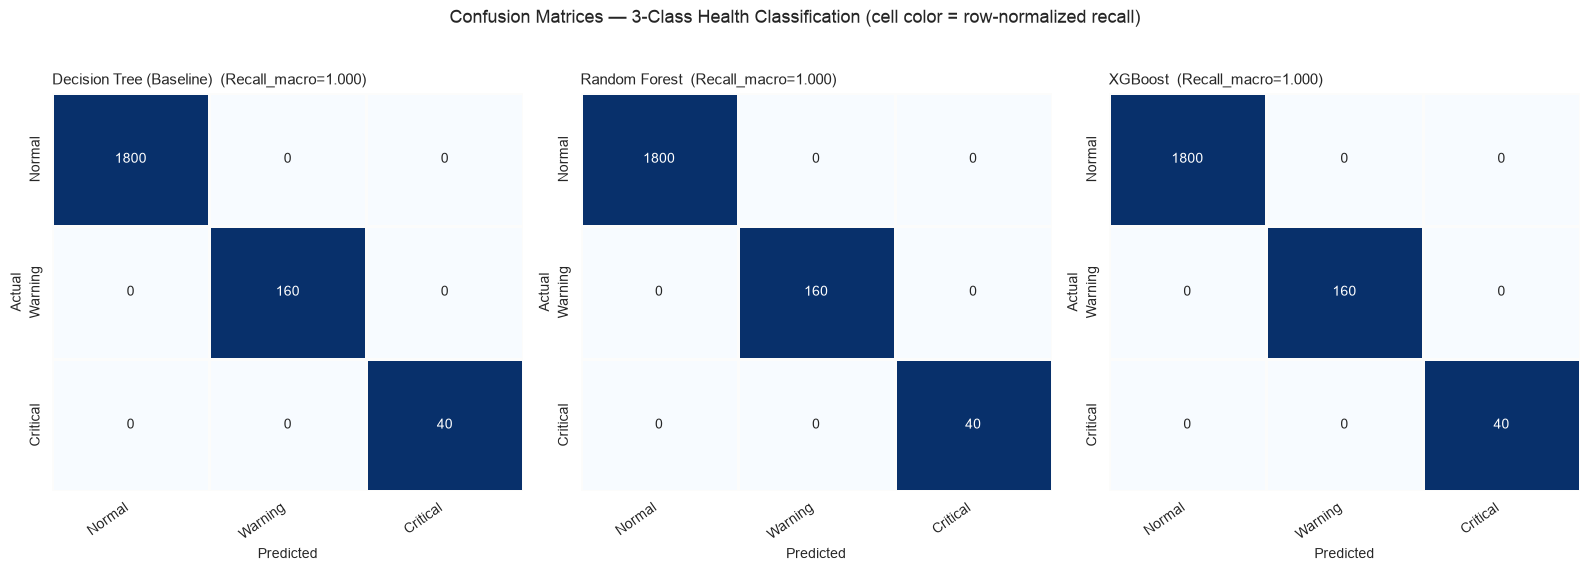

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, result in zip(axes.flat, classification_results):
    cm = result["_confusion_matrix"]
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    sns.heatmap(
        cm_pct, annot=cm, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=1, linecolor=SURFACE,
        vmin=0, vmax=1,
    )
    ax.set_title(f"{result['Model']}  (Recall_macro={result['Recall']:.3f})", fontsize=11, loc="left")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.suptitle("Confusion Matrices — 3-Class Health Classification (cell color = row-normalized recall)", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_classification_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()


In [27]:
recall_per_class = []
for result in classification_results:
    per_class_recall = recall_score(
        y_test_clf, result["_y_pred"], labels=all_class_labels, average=None, zero_division=0
    )
    recall_per_class.append({"Model": result["Model"], **dict(zip(CLASS_NAMES, per_class_recall))})
recall_per_class_df = pd.DataFrame(recall_per_class).set_index("Model").round(3)
test_support = y_test_clf.value_counts().reindex(all_class_labels, fill_value=0)
test_support.index = CLASS_NAMES
print(f"Test-set support per class: {test_support.to_dict()}")
print("Per-class recall (0 support -> recall is undefined/0 by convention, not a real miss):")
recall_per_class_df

Test-set support per class: {'Normal': 1800, 'Warning': 160, 'Critical': 40}
Per-class recall (0 support -> recall is undefined/0 by convention, not a real miss):


,Normal,Warning,Critical
Model,,,
Decision Tree (Baseline),1.0,1.0,1.0
Random Forest,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0


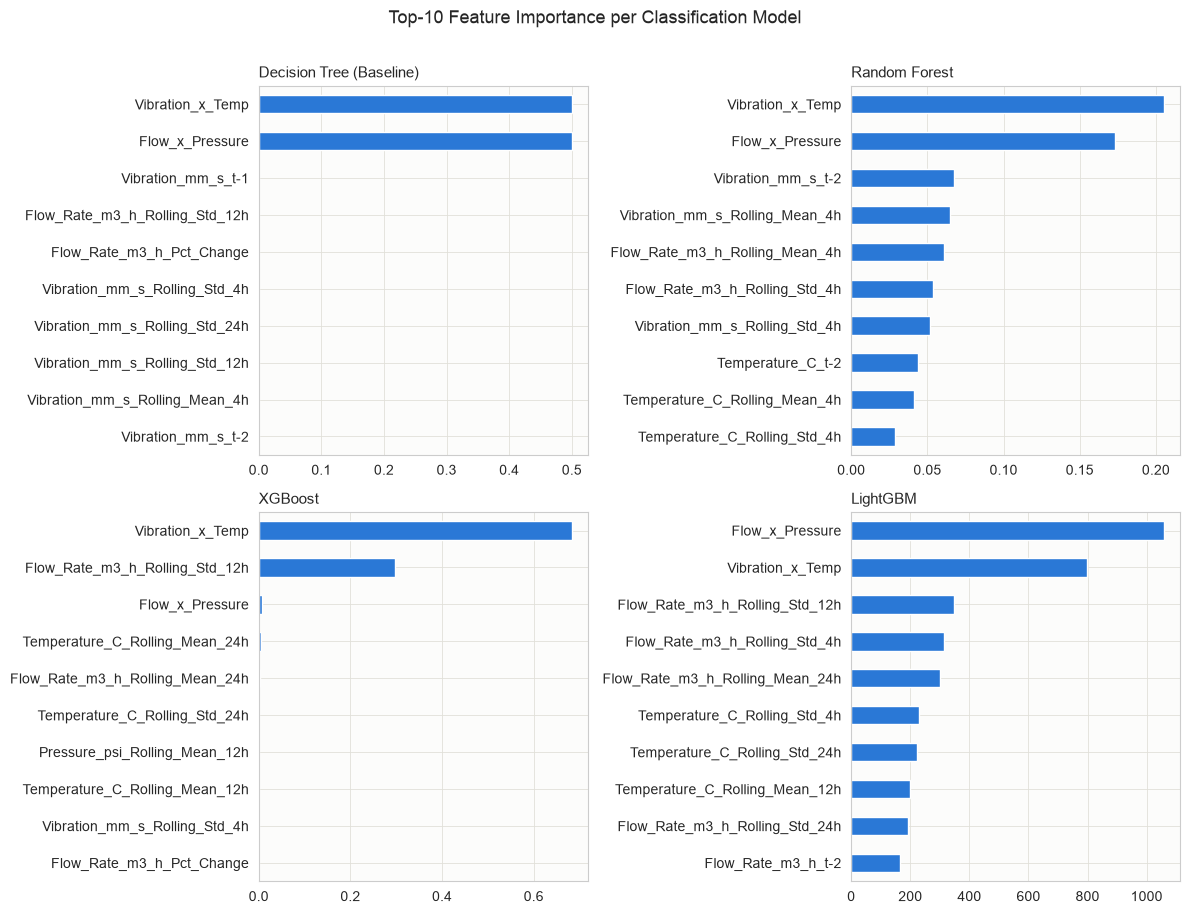

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, model) in zip(axes.flat, fitted_classifiers.items()):
    importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False).head(10)
    importances.sort_values().plot.barh(ax=ax, color=CAT[0])
    ax.set_title(name, fontsize=11, loc="left")
fig.suptitle("Top-10 Feature Importance per Classification Model", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_classification_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

### 7b. Regression Models — Remaining Useful Life


In [29]:
regressors = {
    "Decision Tree (Baseline)": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    ),
}

regression_results = []
fitted_regressors = {}
for name, model in regressors.items():
    model.fit(X_train, y_train_reg)
    fitted_regressors[name] = model
    result = u.evaluate_regressor(name, model, X_test, y_test_reg, X_train, y_train_reg)
    regression_results.append(result)
    print(f"{name:28s} done.")

Decision Tree (Baseline)     done.


Random Forest                done.


XGBoost                      done.


LightGBM                     done.


In [30]:
reg_metrics_df = pd.DataFrame(regression_results).drop(columns=["_y_pred"]).set_index("Model").round(3)
reg_metrics_df

,MAE,RMSE,R2_Score,CV_MAE_Mean,CV_MAE_Std
Model,,,,,
Decision Tree (Baseline),38.084,50.819,0.876,41.042,1.294
Random Forest,37.613,50.103,0.880,38.635,0.962
XGBoost,39.146,52.341,0.869,37.029,0.888
LightGBM,39.563,52.652,0.867,37.374,0.919


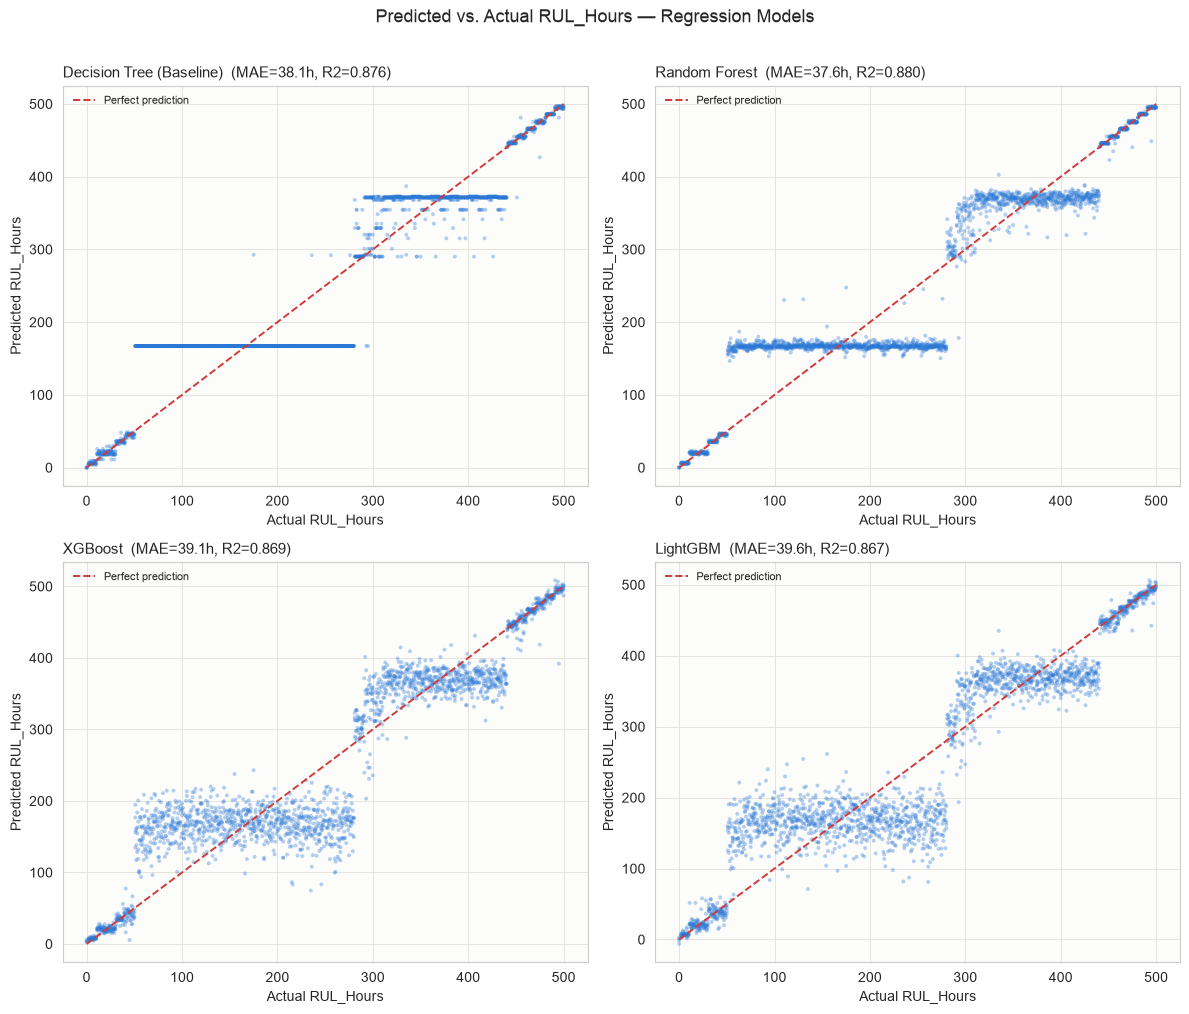

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, result in zip(axes.flat, regression_results):
    y_pred = result["_y_pred"]
    ax.scatter(y_test_reg, y_pred, s=8, alpha=0.35, color=CAT[0], edgecolors="none")
    lims = [0, y_test_reg.max()]
    ax.plot(lims, lims, color=STATUS["Critical"], linewidth=1.4, linestyle="--", label="Perfect prediction")
    ax.set_title(f"{result['Model']}  (MAE={result['MAE']:.1f}h, R2={result['R2_Score']:.3f})", fontsize=11, loc="left")
    ax.set_xlabel("Actual RUL_Hours")
    ax.set_ylabel("Predicted RUL_Hours")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Predicted vs. Actual RUL_Hours — Regression Models", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_regression_predicted_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()

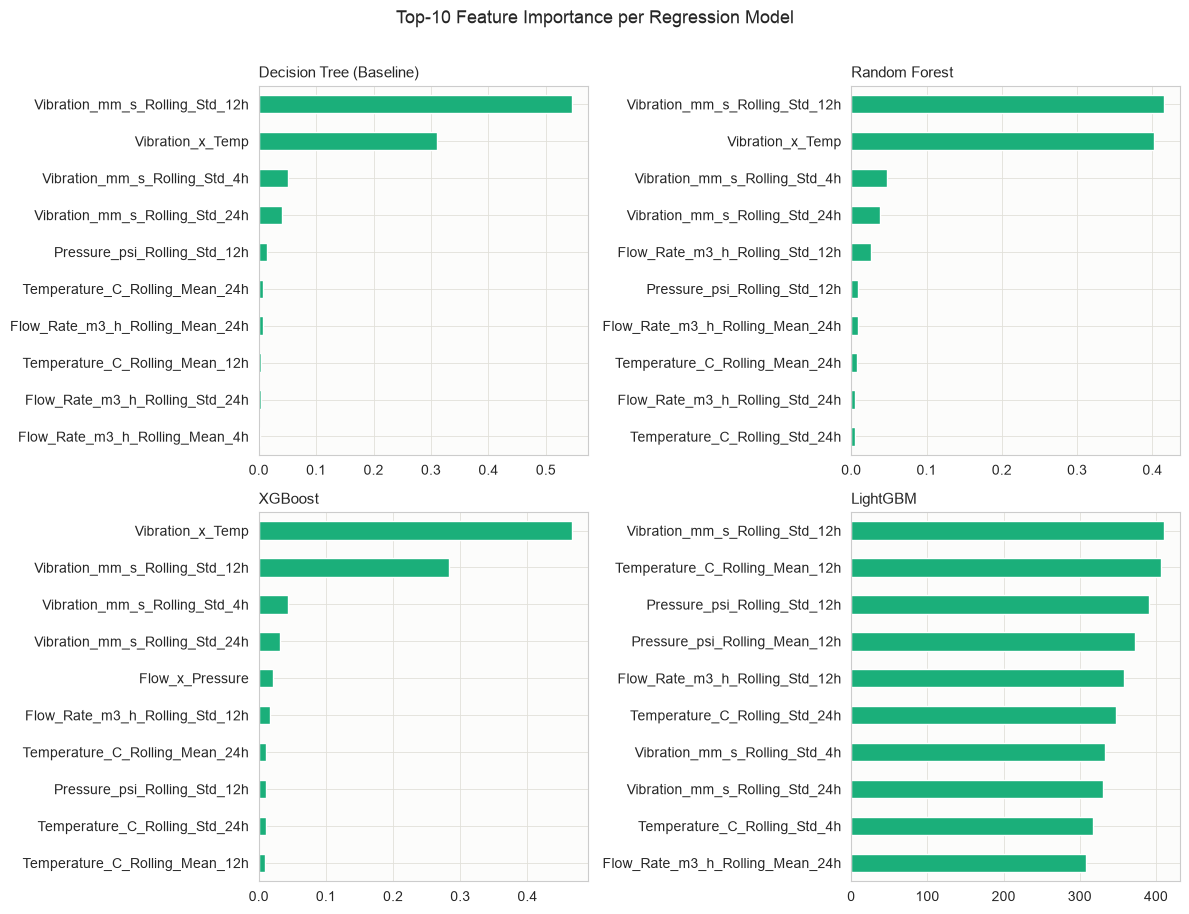

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, model) in zip(axes.flat, fitted_regressors.items()):
    importances = pd.Series(model.feature_importances_, index=final_features).sort_values(ascending=False).head(10)
    importances.sort_values().plot.barh(ax=ax, color=CAT[1])
    ax.set_title(name, fontsize=11, loc="left")
fig.suptitle("Top-10 Feature Importance per Regression Model", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_regression_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Model Comparison & Recommendation


In [33]:
print("=== Classification model comparison (macro-averaged across all 3 health classes) ===")
display_class = class_metrics_df.copy()
display_class.insert(0, "Rank_by_Recall", display_class["Recall"].rank(ascending=False).astype(int))
display_class.sort_values("Recall", ascending=False)

=== Classification model comparison (macro-averaged across all 3 health classes) ===


,Rank_by_Recall,Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_F1_Mean,CV_F1_Std
Model,,,,,,,,
Decision Tree (Baseline),2,1.0,1.0,1.0,1.0,1.0,1.0000,0.0000
Random Forest,2,1.0,1.0,1.0,1.0,1.0,1.0000,0.0000
XGBoost,2,1.0,1.0,1.0,1.0,1.0,0.9997,0.0006
LightGBM,2,1.0,1.0,1.0,1.0,1.0,1.0000,0.0000


In [34]:
print("=== Classification: per-class recall comparison (the more actionable view) ===")
recall_per_class_df.sort_values("Warning", ascending=False)

=== Classification: per-class recall comparison (the more actionable view) ===


,Normal,Warning,Critical
Model,,,
Decision Tree (Baseline),1.0,1.0,1.0
Random Forest,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0


In [35]:
print("=== Regression model comparison ===")
display_reg = reg_metrics_df.copy()
display_reg.insert(0, "Rank_by_MAE", display_reg["MAE"].rank(ascending=True).astype(int))
display_reg.sort_values("MAE")

=== Regression model comparison ===


,Rank_by_MAE,MAE,RMSE,R2_Score,CV_MAE_Mean,CV_MAE_Std
Model,,,,,,
Random Forest,1,37.613,50.103,0.880,38.635,0.962
Decision Tree (Baseline),2,38.084,50.819,0.876,41.042,1.294
XGBoost,3,39.146,52.341,0.869,37.029,0.888
LightGBM,4,39.563,52.652,0.867,37.374,0.919


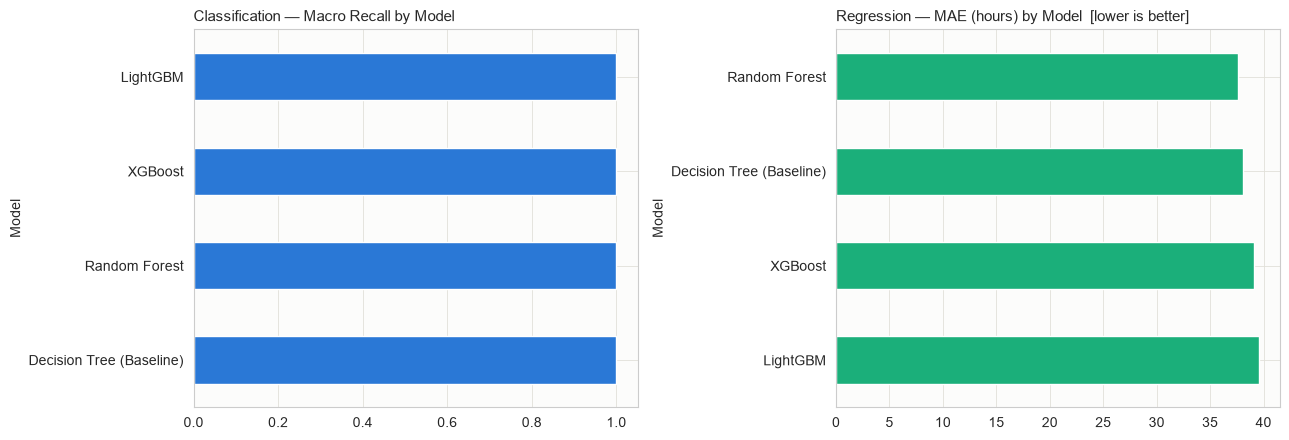

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

class_metrics_df["Recall"].sort_values().plot.barh(ax=axes[0], color=[CAT[0]] * len(class_metrics_df))
axes[0].set_title("Classification — Macro Recall by Model", loc="left", fontsize=11)
axes[0].set_xlim(0, 1.05)

reg_metrics_df["MAE"].sort_values(ascending=False).plot.barh(ax=axes[1], color=[CAT[1]] * len(reg_metrics_df))
axes[1].set_title("Regression — MAE (hours) by Model  [lower is better]", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_model_comparison_summary.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Model Persistence


In [37]:
import model_persistence as mp
import model_registry as mr

best_recall = class_metrics_df["Recall"].max()
models_tied_at_best_recall = class_metrics_df.index[class_metrics_df["Recall"] == best_recall].tolist()
best_classifier_name = "LightGBM" if "LightGBM" in models_tied_at_best_recall else class_metrics_df["Recall"].idxmax()
best_regressor_name = reg_metrics_df["CV_MAE_Mean"].idxmin()

best_classifier = fitted_classifiers[best_classifier_name]
best_regressor = fitted_regressors[best_regressor_name]

print(f"Models tied at best macro Recall ({best_recall:.3f}): {models_tied_at_best_recall}")
print(f"Best classifier (macro Recall, LightGBM preferred on ties) : {best_classifier_name} -> Recall={class_metrics_df.loc[best_classifier_name, 'Recall']:.3f}")
print(f"Best regressor  (CV MAE)       : {best_regressor_name} -> CV_MAE_Mean={reg_metrics_df.loc[best_regressor_name, 'CV_MAE_Mean']:.2f}h")


Models tied at best macro Recall (1.000): ['Decision Tree (Baseline)', 'Random Forest', 'XGBoost', 'LightGBM']
Best classifier (macro Recall, LightGBM preferred on ties) : LightGBM -> Recall=1.000
Best regressor  (CV MAE)       : XGBoost -> CV_MAE_Mean=37.03h


In [38]:
feature_engineering_config = {
    "raw_numeric_cols": u.RAW_NUMERIC_COLS,
    "rolling_windows": u.ROLLING_WINDOWS,
    "lag_steps": list(u.LAG_STEPS),
    "interaction_pairs": [
        ("Temperature_C", "Pressure_psi"),
        ("Vibration_mm_s", "Temperature_C"),
        ("Vibration_mm_s", "Pressure_psi"),
        ("Flow_Rate_m3_h", "Pressure_psi"),
    ],
    "categorical_cols": ["Machine_Model"],
    "min_history_readings_recommended": max(u.ROLLING_WINDOWS.values()),
}

new_version = mr.register_version(
    classifier=best_classifier,
    classifier_name=best_classifier_name,
    regressor=best_regressor,
    regressor_name=best_regressor_name,
    scaler=scaler,
    encoders=encoders,
    feature_list=final_features,
    class_names=CLASS_NAMES,
    feature_engineering_config=feature_engineering_config,
    fault_diagnosis_baseline=fault_diagnosis_baseline,
    models_root="models",
    dataset_version="AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx",
    performance_metrics={
        "classifier_test_recall_macro": round(float(class_metrics_df.loc[best_classifier_name, "Recall"]), 4),
        "regressor_test_mae_hours": round(float(reg_metrics_df.loc[best_regressor_name, "MAE"]), 2),
        "n_training_rows": int(len(X_train)),
        "architecture": "3-class health classifier (Normal/Warning/Critical) + separate rule-based fault_diagnosis module for Critical predictions",
    },
    repo_dir=".",
    promote_to_stable=True,
)
print(f"Registered as {new_version}.")
print(mr.list_versions("models"))


2026-07-15 14:41:22,857 [INFO] model_persistence: Saving model artifacts to /Users/rohanpagadala/Downloads/AI_Predictive/models/v3


2026-07-15 14:41:22,860 [INFO] model_persistence: Saved classification_model_lightgbm.joblib (LGBMClassifier)


2026-07-15 14:41:22,863 [INFO] model_persistence: Saved regression_model_xgboost.joblib (XGBRegressor)


2026-07-15 14:41:22,863 [INFO] model_persistence: Saved feature_scaler.joblib (FeatureScaler)


2026-07-15 14:41:22,864 [INFO] model_persistence: Saved label_encoders.joblib (LabelEncoders)


...

2026-07-15 14:41:22,864 [INFO] model_persistence: Saved feature_engineering_config.joblib (dict)


2026-07-15 14:41:22,865 [INFO] model_persistence: Saved fault_diagnosis_baseline.json


2026-07-15 14:41:22,865 [INFO] model_persistence: Saved metadata.json


2026-07-15 14:41:22,865 [INFO] model_persistence: All 9 artifacts saved successfully.


Registered as v3.
[{'version': 'v1', 'is_stable': False, 'is_latest': False, 'model_version': 'v1', 'training_date': '2026-07-15T03:43:29.751830+00:00', 'dataset_version': 'AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx', 'git_commit_hash': 'da1bc3fbbaf4c07e8919347b052107866432ddac', 'classifier_test_recall_macro': 0.8, 'regressor_test_mae_hours': 39.62, 'n_training_rows': 8000}, {'version': 'v2', 'is_stable': False, 'is_latest': False, 'model_version': 'v2', 'training_date': '2026-07-15T04:26:11.505422+00:00', 'dataset_version': 'AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx', 'git_commit_hash': 'da1bc3fbbaf4c07e8919347b052107866432ddac', 'classifier_test_recall_macro': 1.0, 'regressor_test_mae_hours': 39.15, 'n_training_rows': 8000, 'architecture': '3-class health classifier (Normal/Warning/Critical) + separate rule-based fault_diagnosis module for Critical predictions'}, {'version': 'v3', 'is_stable': True, 'is_latest': True, 'model_version': 'v3', 'training_date': '2026-07-1

Build and persist the drift-detection reference and SHAP background sample for the newly registered version -- both are read directly from the version directory at serve time (`app/model_loader.py`), not part of `model_persistence`'s managed artifact set.


In [39]:
from app import drift_detection as dd, explainability as xai

version_dir = f"models/{new_version}"

drift_reference = dd.build_reference_from_raw_data(df_raw)
dd.save_reference(drift_reference, f"{version_dir}/{dd.REFERENCE_FILENAME}")

background_sample = df_fe[final_features].sample(n=min(500, len(df_fe)), random_state=RANDOM_STATE)
joblib.dump(background_sample, f"{version_dir}/{xai.BACKGROUND_SAMPLE_FILENAME}")
print(f"Saved {dd.REFERENCE_FILENAME} and {xai.BACKGROUND_SAMPLE_FILENAME} to {version_dir}")


Saved drift_reference.joblib and shap_background_sample.joblib to models/v3


/Users/rohanpagadala/Downloads/AI_Predictive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
artifacts = mr.load_models_from_registry("models", version=new_version)
print(f"Loaded classifier : {artifacts.classifier_name} ({type(artifacts.classifier).__name__})")
print(f"Loaded regressor  : {artifacts.regressor_name} ({type(artifacts.regressor).__name__})")
print(f"Feature count      : {len(artifacts.feature_list)}")
print(f"Class names        : {artifacts.class_names}")
print(f"Metadata           : {json.dumps(artifacts.metadata, indent=2)}")


2026-07-15 14:41:23,126 [INFO] model_persistence: Loading model artifacts from /Users/rohanpagadala/Downloads/AI_Predictive/models/v3 (saved 2026-07-15T09:11:22.865306+00:00)


2026-07-15 14:41:23,128 [INFO] model_persistence: Loaded classification_model_lightgbm.joblib (LGBMClassifier)


2026-07-15 14:41:23,130 [INFO] model_persistence: Loaded regression_model_xgboost.joblib (XGBRegressor)


2026-07-15 14:41:23,131 [INFO] model_persistence: Loaded feature_scaler.joblib (FeatureScaler)


2026-07-15 14:41:23,131 [INFO] model_persistence: Loaded label_encoders.joblib (LabelEncoders)


2026-07-15 14:41:23,131 [INFO] model_persistence: Loaded selected_features.joblib (list)


2026-07-15 14:41:23,131 [INFO] model_persistence: Loaded class_names.joblib (list)


2026-07-15 14:41:23,132 [INFO] model_persistence: Loaded feature_engineering_config.joblib (dict)


2026-07-15 14:41:23,132 [INFO] model_persistence: All artifacts loaded successfully.


Loaded classifier : LightGBM (LGBMClassifier)
Loaded regressor  : XGBoost (XGBRegressor)
Feature count      : 33
Class names        : ['Normal', 'Warning', 'Critical']
Metadata           : {
  "classifier_name": "LightGBM",
  "classifier_filename": "classification_model_lightgbm.joblib",
  "regressor_name": "XGBoost",
  "regressor_filename": "regression_model_xgboost.joblib",
  "n_features": 33,
  "class_names": [
    "Normal",
    "Warning",
    "Critical"
  ],
  "saved_at_utc": "2026-07-15T09:11:22.865306+00:00",
  "joblib_version": "1.5.3",
  "model_version": "v3",
  "training_date": "2026-07-15T09:11:22.829587+00:00",
  "dataset_version": "AI_Predictive_Maintenance_Pump_Dataset_10000.xlsx",
  "git_commit_hash": "da1bc3fbbaf4c07e8919347b052107866432ddac",
  "classifier_test_recall_macro": 1.0,
  "regressor_test_mae_hours": 39.15,
  "n_training_rows": 8000,
  "architecture": "3-class health classifier (Normal/Warning/Critical) + separate rule-based fault_diagnosis module for Critical

In [41]:
sample = X_test.sample(5, random_state=RANDOM_STATE)

predictions = mp.predict(artifacts, sample)
predictions["RUL_Hours_Actual"] = y_test_reg.loc[sample.index].values
predictions["Failure_Class_Actual"] = y_test_clf.loc[sample.index].map(dict(enumerate(CLASS_NAMES))).values
predictions

,Failure_Class_Predicted,Failure_State_Predicted,RUL_Hours_Predicted,RUL_Hours_Actual,Failure_Class_Actual
9460,0,Normal,326.847839,282,Normal
1953,0,Normal,379.208374,437,Normal
6933,0,Normal,362.874054,327,Normal
4905,0,Normal,393.698151,391,Normal
6489,0,Normal,162.716949,208,Normal


In [42]:
original_class_pred = best_classifier.predict(sample[final_features])
original_reg_pred = best_regressor.predict(sample[final_features])

assert (predictions["Failure_Class_Predicted"].values == original_class_pred).all(), "Classifier predictions diverged after reload!"
assert np.allclose(predictions["RUL_Hours_Predicted"].values, original_reg_pred), "Regressor predictions diverged after reload!"
print("Round-trip verified: loaded models reproduce identical predictions to the original in-memory models.")

Round-trip verified: loaded models reproduce identical predictions to the original in-memory models.
